# Trabajo Práctico Integrado — Probabilidad y Estadística
## Análisis estadístico de las contrataciones públicas del Paraguay (DNCP, 2021–2022)

*Maestría en Ciencia de Datos · Análisis de una base de datos de acceso abierto*

---

## 1. Descripción del dataset y el problema

**Fuente.** Portal de la **Dirección Nacional de Contrataciones Públicas (DNCP)** del Paraguay — datos abiertos publicados en el estándar internacional **OCDS** (*Open Contracting Data Standard*). Cita: DNCP, *Datos Abiertos de Contrataciones*, https://www.contrataciones.gov.py/datos.

**Contexto.** Cada registro corresponde a un **proceso de contratación pública** de los años **2021 y 2022**. Trabajamos con los procesos **efectivamente completados y adjudicados**. Para cada uno el dataset informa el monto, la modalidad y el método de contratación, la categoría (bien / servicio / obra), la institución compradora, el número de oferentes y las fechas del proceso.

**Variable de monto — aclaración importante.** El monto proviene del campo OCDS `tender/value/amount`, que según la documentación del estándar corresponde al **valor total estimado del proceso** (*"the total upper estimated value of the procurement"*). Es decir, es el **monto licitado / estimado**, **no** el monto finalmente adjudicado (ese se publica en un dataset distinto, `awards/value/amount`, fuera del alcance de este trabajo). Por eso, en todo el informe la variable se denomina **monto licitado**.

**Pregunta de investigación (central).**
> *¿Difieren el **monto licitado** y la **proporción de procesos con más de un oferente** entre 2021 y 2022, y qué características del proceso se relacionan con el monto licitado?*

**Preguntas / hipótesis específicas por sección.**
- **Estimación (IC 95%).** ¿Cuál es el monto licitado típico y la proporción de procesos con competencia en la población?
- **Prueba de hipótesis 1 (medias).** ¿Difiere el monto licitado medio entre 2021 y 2022?  → H₀: μ₂₀₂₁ = μ₂₀₂₂.
- **Prueba de hipótesis 2 (proporciones).** ¿Difiere la proporción de procesos con competencia entre 2021 y 2022?  → H₀: p₂₀₂₁ = p₂₀₂₂.
- **Regresión.** ¿Qué variables del proceso (tipo, modalidad, oferentes, duración) se relacionan con el monto licitado?

### Preparación del entorno y carga de datos

In [1]:
# Dependencias (en Colab descomentar la línea siguiente)
# %pip install -q pandas numpy scipy statsmodels seaborn matplotlib gdown==5.2.0

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 4.5)
plt.rcParams['font.size'] = 11
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

In [2]:
# Carga de los CSV. Busca los archivos localmente (misma carpeta o ./data);
# si no están, los descarga de una carpeta pública de Google Drive con gdown.
import os

ARCHIVOS = ['records_contratos_2021.csv', 'records_contratos_2022.csv']
URL_DATASET = 'https://drive.google.com/drive/folders/1u3rRbpS0ioVadkA5HS_peP6CpwrMXouw'

def ruta_datos(nombre):
    """Ruta del CSV, buscando en la carpeta actual, ./data y ../data."""
    for carpeta in ('.', 'data', '../data'):
        p = os.path.join(carpeta, nombre)
        if os.path.exists(p):
            return p
    return None

if all(ruta_datos(a) for a in ARCHIVOS):
    print('CSV encontrados localmente:', [ruta_datos(a) for a in ARCHIVOS])
else:
    import gdown
    os.makedirs('data', exist_ok=True)
    gdown.download_folder(url=URL_DATASET, output='data', quiet=True)
    print('CSV descargados en ./data')

CSV encontrados localmente: ['../data\\records_contratos_2021.csv', '../data\\records_contratos_2022.csv']


**Nota sobre los archivos.** El portal DNCP publica los mismos procesos bajo dos endpoints, *contratos* (`records_contratos_*.csv`) y *adjudicaciones* (`records_adj_*.csv`); verificamos que ambos archivos son **idénticos**, por lo que usamos uno solo. Cada CSV trae 66 columnas OCDS; de ellas seleccionamos directamente las que necesita el análisis (celda siguiente).

In [3]:
# ---------- Carga y limpieza (versión mínima y reproducible) ----------
# Seleccionamos SOLO las columnas necesarias y las renombramos a nombres claros.
COLS = {
    'compiledRelease/id':                                'id_proceso',
    'compiledRelease/tender/title':                      'titulo',
    'compiledRelease/tender/status':                     'estado',
    'compiledRelease/tender/statusDetails':              'detalle_estado',
    'compiledRelease/tender/value/amount':               'monto_licitado',   # OCDS tender/value = valor estimado
    'compiledRelease/tender/value/currency':             'moneda',
    'compiledRelease/tender/numberOfTenderers':          'num_oferentes',
    'compiledRelease/tender/tenderPeriod/durationInDays': 'duracion_dias_licitacion',
    'compiledRelease/tender/mainProcurementCategory':    'tipo',
    'compiledRelease/tender/procurementMethodDetails':   'modalidad',
    'compiledRelease/buyer/name':                        'institucion',
}
TIPO_CAMBIO = 7200  # PYG por USD: tipo de cambio de referencia promedio 2021-2022 (Banco Central del Paraguay).

def leer(anio):
    d = pd.read_csv(ruta_datos(f'records_contratos_{anio}.csv'),
                    usecols=list(COLS), low_memory=False).rename(columns=COLS)
    d['anio'] = anio
    return d

# 1) Unir 2021 + 2022 y quitar procesos duplicados (mismo id de proceso)
df_crudo = pd.concat([leer(2021), leer(2022)], ignore_index=True).drop_duplicates(subset='id_proceso')

# 2) Conservar solo los procesos completados y adjudicados
df = df_crudo[(df_crudo['estado'] == 'complete') &
              (df_crudo['detalle_estado'] == 'Adjudicada')].copy()

# 3) Verificar las monedas presentes ANTES de convertir (para justificar la conversión)
print('Frecuencia de la variable moneda (procesos adjudicados):')
print(df['moneda'].value_counts(dropna=False))

# 4) Convertir el monto a USD: SOLO los montos en guaraníes (PYG) se dividen por el tc;
#    los que ya están en USD se dejan igual.
monto = pd.to_numeric(df['monto_licitado'], errors='coerce')
df['monto_usd'] = monto.where(df['moneda'] == 'USD', monto / TIPO_CAMBIO).round(2)

# 5) Variables derivadas para el análisis
df['tipo_es']     = df['tipo'].map({'goods': 'Bienes', 'services': 'Servicios', 'works': 'Obras'})
df['competencia'] = (df['num_oferentes'] > 1).astype('Int64')   # 1 = más de un oferente
df.loc[df['num_oferentes'].isna(), 'competencia'] = pd.NA       # oferentes desconocido => faltante (no cuenta como 0)

print(f"\nProcesos adjudicados: {df.shape[0]:,}  |  por año: {dict(df['anio'].value_counts())}")

Frecuencia de la variable moneda (procesos adjudicados):
moneda
PYG    23948
USD       34
Name: count, dtype: int64

Procesos adjudicados: 23,982  |  por año: {2022: np.int64(18567), 2021: np.int64(5415)}


## 2. Identificación y clasificación de variables

Se seleccionan **6 variables originales** (3 cuantitativas y 3 cualitativas) y se construye **1 variable derivada** (`competencia`). Este conjunto es la **base analítica**; las demás columnas del archivo original se descartan por no intervenir en las preguntas planteadas.

| Variable | Descripción | Tipo | Escala |
|---|---|---|---|
| `monto_usd` | **Monto licitado** (estimado) del proceso, convertido a USD (tc = 7.200 PYG/USD) | Cuantitativa **continua** | Razón |
| `num_oferentes` | Cantidad de oferentes presentados al llamado | Cuantitativa **discreta** | Razón |
| `duracion_dias_licitacion` | Duración del período de licitación (días) | Cuantitativa **discreta** | Razón |
| `tipo_es` | Categoría principal de la compra | Cualitativa **nominal** | Bienes / Servicios / Obras |
| `modalidad` | Modalidad del proceso de contratación | Cualitativa **nominal** | Contratación Directa, Concurso de Ofertas, … |
| `anio` | Año del proceso | Cualitativa **nominal** (binaria) | 2021 / 2022 |

**Variable derivada.** A partir de `num_oferentes` se construye **`competencia`** (cualitativa nominal **binaria**): **1** si hubo *competencia efectiva* (más de un oferente) y **0** si se presentó un único oferente. Se usa para la estimación e inferencia sobre proporciones.

> `monto_usd` es **continua**: aunque se exprese en dinero, puede tomar cualquier valor real positivo.

## 3. Limpieza y preparación de los datos

La celda de carga ya dejó la **base analítica** lista (selección de columnas, filtro de procesos adjudicados, conversión de moneda y variables derivadas). A continuación se cuantifican los tres aspectos exigidos: **valores faltantes**, **valores atípicos** y **transformaciones**. Al final se documenta la **cobertura por año**.

In [4]:
# --- Valores faltantes en las variables del análisis (cantidad y %) ---
analisis = ['monto_usd', 'num_oferentes', 'duracion_dias_licitacion',
            'tipo_es', 'modalidad', 'anio', 'competencia']
faltantes = pd.DataFrame({
    'faltantes': df[analisis].isna().sum(),
    '%': (df[analisis].isna().mean() * 100).round(1),
})
print(f'VALORES FALTANTES por variable (sobre {df.shape[0]:,} procesos adjudicados):')
print(faltantes)

VALORES FALTANTES por variable (sobre 23,982 procesos adjudicados):
                          faltantes    %
monto_usd                       112 0.50
num_oferentes                  1124 4.70
duracion_dias_licitacion       1191 5.00
tipo_es                           0 0.00
modalidad                         0 0.00
anio                              0 0.00
competencia                    1124 4.70


In [5]:
# --- Valores atípicos en monto_usd (regla del rango intercuartílico, IQR) ---
m = df['monto_usd'].dropna()
q1, q3 = m.quantile([.25, .75]); iqr = q3 - q1
lim_sup = q3 + 1.5 * iqr
n_out = (m > lim_sup).sum()
cv = m.std() / m.mean() * 100                      # coeficiente de variación (explícito)
print(f"Q1={q1:,.0f}  Q3={q3:,.0f}  IQR={iqr:,.0f}  límite superior={lim_sup:,.0f}")
print(f"Outliers por encima del límite: {n_out:,} ({n_out/len(m)*100:.1f}% de los montos)")
print(f"Máximo: {m.max():,.0f} USD  |  asimetría (skew): {m.skew():.1f}  |  CV: {cv:.0f}%")

# Verificación: los 8 procesos de mayor monto (que son reales, no errores de carga)
print("\nProcesos de mayor monto licitado (título, tipo, institución, moneda):")
top = df.nlargest(8, 'monto_usd')[['titulo', 'tipo_es', 'institucion', 'moneda', 'monto_usd']].copy()
top['titulo'] = top['titulo'].str.slice(0, 50) + '…'
top['institucion'] = top['institucion'].str.slice(0, 32)
print(top.to_string(index=False))

Q1=10,914  Q3=49,722  IQR=38,809  límite superior=107,935
Outliers por encima del límite: 3,186 (13.3% de los montos)
Máximo: 73,151,373 USD  |  asimetría (skew): 27.0  |  CV: 843%

Procesos de mayor monto licitado (título, tipo, institución, moneda):
                                             titulo tipo_es                      institucion moneda     monto_usd
ADQUISICIÓN DE MEDICAMENTOS VARIOS Y DESINFECTANTE…  Bienes Ministerio de Salud Pública y Bi    PYG 73,151,373.18
MOPC 123-12FIRMAS CONSTR P/LA EJECUCION DE LA OBRA…   Obras Ministerio de Obras Públicas y C    PYG 64,263,888.89
LPN N° 02/16 "CONSTRUCCIONES, AMPLIACIONES Y REPAR…   Obras Ministerio de Educación y Cienci    PYG 55,829,526.28
MOPC Nº 52-13 LPI EMP. CONSTRUCTORAS ESPECIALIZADA…   Obras Ministerio de Obras Públicas y C    PYG 55,555,555.56
HABILITACION DE LA RN Nº 9.TRAMO MCAL. ESTIGARRIBI…   Obras Ministerio de Obras Públicas y C    PYG 53,347,861.11
LPN SBE 73-18 ADQUISICION DE MEDICAMENTOS VARIOS P…  Bienes Inst

In [6]:
# --- Transformación: log10 del monto (para montos > 0) y subconjunto de análisis de montos ---
dfa = df[df['monto_usd'].notna() & (df['monto_usd'] > 0)].copy()
dfa['log_monto'] = np.log10(dfa['monto_usd'])
print(f"Subconjunto con monto>0 para análisis monetario: {len(dfa):,} filas "
      f"(se excluyen {len(df)-len(dfa):,} con monto nulo o cero)")

Subconjunto con monto>0 para análisis monetario: 23,853 filas (se excluyen 129 con monto nulo o cero)


In [7]:
# --- Cobertura por año: registros crudos vs. adjudicados (documenta el desbalance) ---
cob = pd.DataFrame({
    'registros_crudos': df_crudo['anio'].value_counts().sort_index(),
    'adjudicados':      df['anio'].value_counts().sort_index(),
})
cob['%_adjudicados'] = (cob['adjudicados'] / cob['registros_crudos'] * 100).round(1)
print(cob)

      registros_crudos  adjudicados  %_adjudicados
anio                                              
2021              9305         5415          58.20
2022             30652        18567          60.60


**Criterios adoptados.**
- **Faltantes.** `num_oferentes` (y por lo tanto `competencia`) y `duracion_dias_licitacion` presentan faltantes (≈5% cada una); `monto_usd` casi no tiene, y las categóricas no tienen. Se aplica **eliminación por lista en cada análisis** (se descartan los faltantes solo de las variables involucradas) y **se reporta el n efectivamente usado** en cada sección.
- **Atípicos.** El monto tiene **asimetría extrema** (skew ≈ 27; **CV ≈ 840%**). Por la regla IQR, ~13% de los montos supera el límite superior. La tabla anterior confirma que los mayores montos son **obras y adquisiciones reales de gran porte** (no errores de carga). **No se eliminan**; se aplica **`log₁₀`** para los gráficos y la regresión, que comprime la escala y aproxima la distribución a la normal.
- **Transformación.** `log₁₀(monto_usd)` para montos > 0; binarización de `competencia`; mapeo de `tipo` a español.
- **Cobertura por año.** 2021 aporta bastantes menos procesos que 2022 (≈5.400 vs ≈18.600). Esto refleja el **volumen real cargado en el portal** (2021: 9.305 registros crudos; 2022: 30.652), con **tasas de adjudicación similares** (58% vs 61%); **no** es un efecto de los filtros aplicados. La diferencia de tamaños no impide las pruebas (usan errores estándar por grupo), pero queda documentada.

## 4. Análisis descriptivo y gráficos

In [8]:
# --- Estadísticos descriptivos de las variables cuantitativas ---
def resumen(s):
    s = pd.to_numeric(s, errors='coerce').dropna()
    return pd.Series({'n':len(s),'media':s.mean(),'mediana':s.median(),'desv_est':s.std(),
                      'mín':s.min(),'máx':s.max(),'CV_%':s.std()/s.mean()*100})
tabla = pd.DataFrame({c: resumen(df[c]) for c in ['monto_usd','num_oferentes','duracion_dias_licitacion']}).T
tabla

,n,media,mediana,desv_est,mín,máx,CV_%
monto_usd,"23,870.00","174,044.35","19,974.26","1,466,580.77",0.00,"73,151,373.18",842.65
num_oferentes,"22,858.00",2.73,2.00,2.44,1.00,43.00,89.48
duracion_dias_licitacion,"22,791.00",13.29,10.00,15.31,0.00,728.00,115.15


C:\Users\SebastianChamorro\AppData\Local\Temp\ipykernel_22464\2444026129.py:9: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\SebastianChamorro\AppData\Local\Temp\ipykernel_22464\2444026129.py:9: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\SebastianChamorro\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SebastianChamorro\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


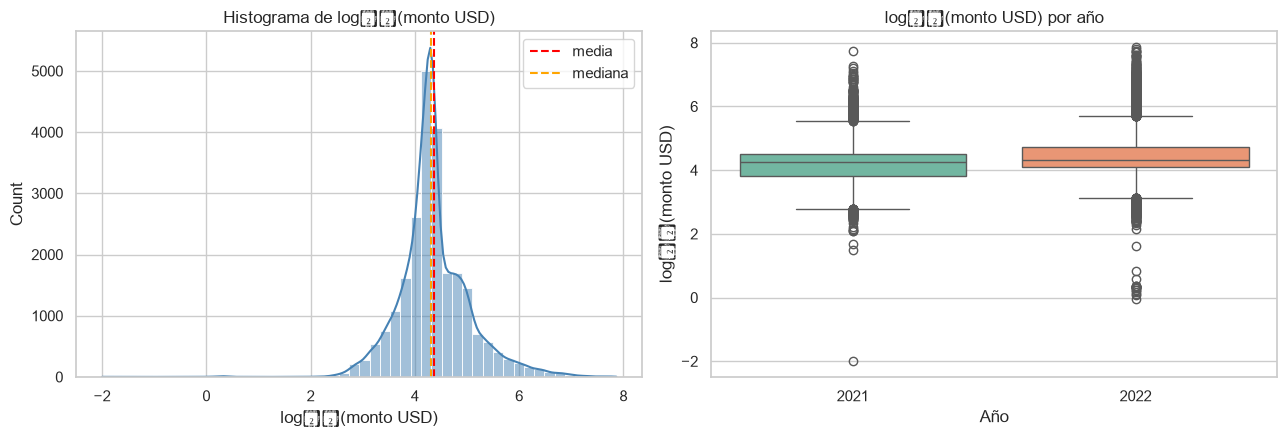

In [9]:
# Gráfico 1 — Distribución del monto (escala log) y por año
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(dfa['log_monto'], bins=50, kde=True, color='steelblue', ax=ax[0])
ax[0].axvline(dfa['log_monto'].mean(), color='red', ls='--', label='media')
ax[0].axvline(dfa['log_monto'].median(), color='orange', ls='--', label='mediana')
ax[0].set(title='Histograma de log₁₀(monto USD)', xlabel='log₁₀(monto USD)'); ax[0].legend()
sns.boxplot(data=dfa, x='anio', y='log_monto', hue='anio', palette='Set2', legend=False, ax=ax[1])
ax[1].set(title='log₁₀(monto USD) por año', xlabel='Año', ylabel='log₁₀(monto USD)')
plt.tight_layout(); plt.show()

**Interpretación (Gráfico 1).** En escala logarítmica el monto es **aproximadamente simétrico y unimodal**, centrado en torno a `log₁₀ ≈ 4,37` (≈ **23.500 USD**, media geométrica). La cercanía entre media y mediana en la escala log confirma que la transformación corrige la fuerte asimetría original (en escala natural la media, 174.044 USD, multiplica por ~9 a la mediana, 19.974 USD). El boxplot por año muestra montos algo **mayores en 2022**.

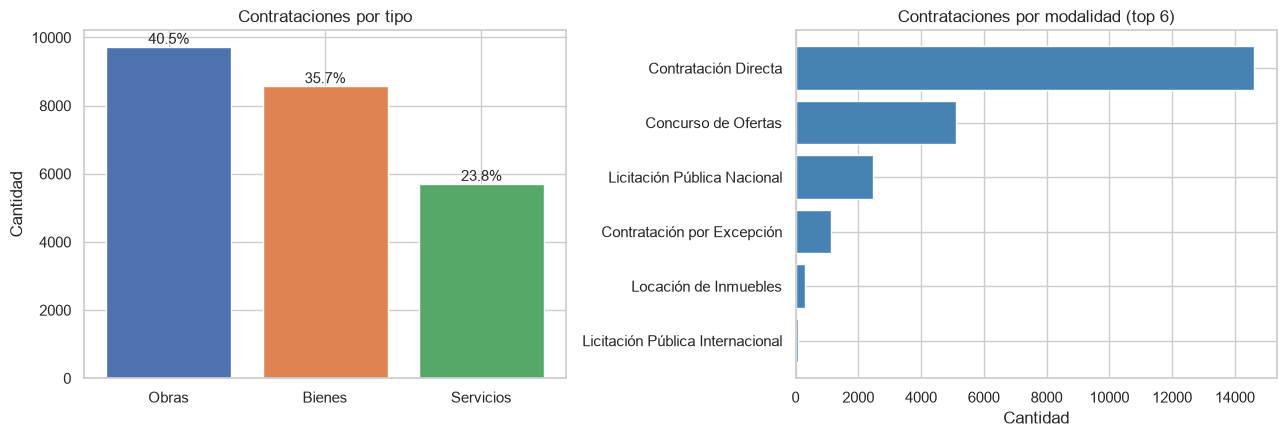

Tipo (%):
tipo_es
Obras       40.50
Bienes      35.70
Servicios   23.80
Name: proportion, dtype: float64

Modalidad (%):
modalidad
Contratación Directa               60.90
Concurso de Ofertas                21.40
Licitación Pública Nacional        10.30
Contratación por Excepción          4.80
Locación de Inmuebles               1.30
Licitación Pública Internacional    0.30
Name: proportion, dtype: float64


In [10]:
# Gráfico 2 — Variables cualitativas: tipo y modalidad
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
tc = df['tipo_es'].value_counts()
ax[0].bar(tc.index, tc.values, color=['#4c72b0','#dd8452','#55a868'])
ax[0].set(title='Contrataciones por tipo', ylabel='Cantidad')
for i,v in enumerate(tc.values): ax[0].text(i, v, f'{v/len(df)*100:.1f}%', ha='center', va='bottom')
mc = df['modalidad'].value_counts().head(6)[::-1]
ax[1].barh(mc.index, mc.values, color='steelblue')
ax[1].set(title='Contrataciones por modalidad (top 6)', xlabel='Cantidad')
plt.tight_layout(); plt.show()

print('Tipo (%):'); print((df['tipo_es'].value_counts(normalize=True)*100).round(1))
print('\nModalidad (%):'); print((df['modalidad'].value_counts(normalize=True)*100).round(1).head(6))

**Interpretación (Gráfico 2).** Las **Obras** son la categoría más frecuente (40,5%), seguidas de **Bienes** (35,7%) y **Servicios** (23,8%): las tres tienen tamaños muestrales amplios, adecuados para comparaciones entre grupos. En modalidad domina de forma marcada la **Contratación Directa** (≈61%), seguida del **Concurso de Ofertas** (≈21%) y la **Licitación Pública Nacional** (≈10%); las modalidades competitivas de mayor cuantía son minoritarias en número de procesos.

## 5. Estimación por intervalos de confianza (95%)

In [11]:
# 5a — IC 95% para la media de log10(monto). n es grande => t ≈ z.
x = dfa['log_monto']; n = len(x); media = x.mean(); ee = x.std(ddof=1)/np.sqrt(n)
tcrit = stats.t.ppf(0.975, n-1)
li, ls = media - tcrit*ee, media + tcrit*ee
print(f"n={n:,}  media(log)={media:.4f}  EE={ee:.5f}  t*={tcrit:.4f}")
print(f"IC95% (log10): ({li:.4f} ; {ls:.4f})")
print(f"IC95% en USD (media geométrica): {10**media:,.0f}  ->  ({10**li:,.0f} ; {10**ls:,.0f})")

n=23,853  media(log)=4.3715  EE=0.00438  t*=1.9601
IC95% (log10): (4.3629 ; 4.3800)
IC95% en USD (media geométrica): 23,521  ->  (23,061 ; 23,991)


**5a — Interpretación.** Con un **95% de confianza**, la **media geométrica** del monto licitado de la población de contrataciones se encuentra entre **23.061 y 23.991 USD** (media puntual ≈ 23.521). El intervalo es **muy angosto** (~930 USD de amplitud) porque el tamaño muestral es grande (n ≈ 23.900), lo que otorga gran precisión a la estimación. *Correctamente*: si repitiéramos el muestreo muchas veces, el 95% de los intervalos así construidos contendrían la verdadera media poblacional.

In [12]:
# 5b — IC 95% para la proporción de procesos con competencia (>1 oferente)
comp = df['competencia'].dropna().astype(int)
k, n = comp.sum(), len(comp); phat = k/n
ee = np.sqrt(phat*(1-phat)/n); z = stats.norm.ppf(0.975)
print(f"éxitos={k:,}  n={n:,}  p̂={phat:.4f}")
print(f"IC95% (aprox. normal): ({phat-z*ee:.4f} ; {phat+z*ee:.4f})")
print(f"IC95% (Wilson):        {tuple(round(v,4) for v in proportion_confint(k, n, method='wilson'))}")

éxitos=14,833  n=22,858  p̂=0.6489
IC95% (aprox. normal): (0.6427 ; 0.6551)
IC95% (Wilson):        (0.6427, 0.6551)


**5b — Interpretación.** Con un **95% de confianza**, la proporción poblacional de contrataciones con **competencia efectiva** (más de un oferente) está entre **64,3% y 65,5%** (estimación puntual 64,9%). Ambos métodos (aproximación normal y Wilson) coinciden hasta el cuarto decimal, gracias al gran `n`. Esto indica que **cerca de un tercio de los procesos recibe una única oferta**, un hallazgo relevante en términos de transparencia y concurrencia.

## 6. Prueba de hipótesis

Se comparan **dos grupos definidos por el año** (2021 vs 2022), con **α = 0,05** en ambas pruebas.

### 6a. Diferencia de medias — prueba *t* de Welch sobre `log₁₀(monto)`

- **H₀:** μ₂₀₂₁ = μ₂₀₂₂  (el monto medio, en escala log, no difiere entre años)
- **H₁:** μ₂₀₂₁ ≠ μ₂₀₂₂  (**contraste bilateral**: no se presume a priori en qué dirección cambia)
- Se usa **t de Welch** porque no se asume igualdad de varianzas entre los grupos.

In [13]:
g21 = dfa[dfa['anio']==2021]['log_monto']; g22 = dfa[dfa['anio']==2022]['log_monto']
t, p = stats.ttest_ind(g21, g22, equal_var=False)
print(f"2021: n={len(g21):,}  media(log)={g21.mean():.4f}  (USD geom {10**g21.mean():,.0f})")
print(f"2022: n={len(g22):,}  media(log)={g22.mean():.4f}  (USD geom {10**g22.mean():,.0f})")
print(f"\nEstadístico t = {t:.3f}   valor p = {p:.3e}")
print('Decisión:', 'se RECHAZA H0' if p < 0.05 else 'no se rechaza H0')

2021: n=5,378  media(log)=4.2294  (USD geom 16,958)
2022: n=18,475  media(log)=4.4128  (USD geom 25,871)

Estadístico t = -17.214   valor p = 2.690e-65
Decisión: se RECHAZA H0


**6a — Conclusión.** t = −17,2 con **p ≈ 2,7×10⁻⁶⁵ < 0,05** ⇒ **se rechaza H₀**. Existe evidencia estadística muy fuerte de que el **monto medio licitado aumentó** de 2021 (≈ 16.958 USD, media geométrica) a 2022 (≈ 25.871 USD). La diferencia es además de magnitud práctica considerable (+53% en la media geométrica).

### 6b. Diferencia de proporciones — prueba *z* sobre `competencia`

- **H₀:** p₂₀₂₁ = p₂₀₂₂  (la proporción de procesos con competencia no difiere entre años)
- **H₁:** p₂₀₂₁ ≠ p₂₀₂₂  (**contraste bilateral**)
- Prueba **z para diferencia de proporciones** (muestras grandes).

In [14]:
c21 = df[df['anio']==2021]['competencia'].dropna().astype(int)
c22 = df[df['anio']==2022]['competencia'].dropna().astype(int)
count = np.array([c21.sum(), c22.sum()]); nobs = np.array([len(c21), len(c22)])
z, p = proportions_ztest(count, nobs)
print(f"2021: p̂={count[0]/nobs[0]:.4f}  (n={nobs[0]:,})")
print(f"2022: p̂={count[1]/nobs[1]:.4f}  (n={nobs[1]:,})")
print(f"\nEstadístico z = {z:.3f}   valor p = {p:.3e}")
print('Decisión:', 'se RECHAZA H0' if p < 0.05 else 'no se rechaza H0')

2021: p̂=0.7247  (n=5,169)
2022: p̂=0.6268  (n=17,689)

Estadístico z = 12.977   valor p = 1.663e-38
Decisión: se RECHAZA H0


**6b — Conclusión.** z = 12,98 con **p ≈ 1,7×10⁻³⁸ < 0,05** ⇒ **se rechaza H₀**. La proporción de procesos con competencia efectiva **cayó** de **72,5% (2021)** a **62,7% (2022)**. Es decir, en 2022 hubo montos mayores pero **menor concurrencia** de oferentes, combinación que amerita atención desde la perspectiva de la eficiencia del gasto público.

## 7. Regresión lineal múltiple

Se estudia **qué variables explican el monto licitado**. La variable respuesta es **log₁₀(monto)**, en escala logarítmica por la fuerte asimetría del monto ya justificada en la sección 3.

- **Modelo:** `log₁₀(monto) ~ num_oferentes + duracion_dias_licitacion + C(tipo_es) + C(modalidad)`
- **Hipótesis global (prueba F):** H₀: todos los coeficientes de pendiente son 0 (el modelo no explica nada) vs. H₁: al menos un coeficiente es distinto de 0.
- **Hipótesis por coeficiente (prueba t):** H₀: βⱼ = 0 vs. H₁: βⱼ ≠ 0, para cada predictor.

Primero se muestra el diagrama de dispersión de una regresión simple ilustrativa (monto vs. número de oferentes) y luego se estima el modelo múltiple.

C:\Users\SebastianChamorro\AppData\Local\Temp\ipykernel_22464\4238740807.py:9: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.xlabel('N.º de oferentes'); plt.ylabel('log₁₀(monto USD)'); plt.tight_layout(); plt.show()
C:\Users\SebastianChamorro\AppData\Local\Temp\ipykernel_22464\4238740807.py:9: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.xlabel('N.º de oferentes'); plt.ylabel('log₁₀(monto USD)'); plt.tight_layout(); plt.show()
C:\Users\SebastianChamorro\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SebastianChamorro\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


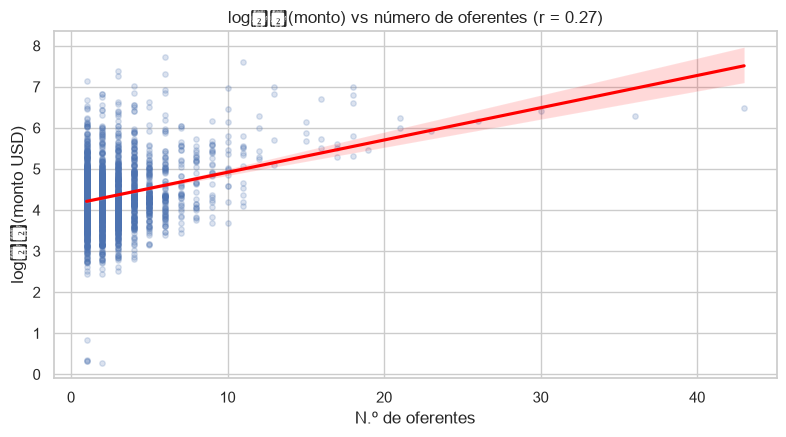

In [15]:
# Gráfico 3 — Diagrama de dispersión (regresión simple ilustrativa: log_monto vs num_oferentes)
sub = dfa.dropna(subset=['num_oferentes']).copy()
sub['num_oferentes'] = sub['num_oferentes'].astype(float)
plt.figure(figsize=(8, 4.5))
sns.regplot(data=sub.sample(3000, random_state=1), x='num_oferentes', y='log_monto',
            scatter_kws={'alpha':0.2, 's':15}, line_kws={'color':'red'})
r, _ = stats.pearsonr(sub['num_oferentes'], sub['log_monto'])
plt.title(f'log₁₀(monto) vs número de oferentes (r = {r:.2f})')
plt.xlabel('N.º de oferentes'); plt.ylabel('log₁₀(monto USD)'); plt.tight_layout(); plt.show()

In [16]:
# Modelo múltiple (modalidad colapsada a top-5 + "Otras")
top5 = dfa['modalidad'].value_counts().head(5).index
dfr = dfa.copy()
dfr['modalidad_g'] = np.where(dfr['modalidad'].isin(top5), dfr['modalidad'], 'Otras')
dfr['num_oferentes'] = pd.to_numeric(dfr['num_oferentes'], errors='coerce')
dfr['duracion_dias_licitacion'] = pd.to_numeric(dfr['duracion_dias_licitacion'], errors='coerce')
dfr = dfr.dropna(subset=['log_monto','num_oferentes','duracion_dias_licitacion','tipo_es','modalidad_g'])
reg = ols('log_monto ~ num_oferentes + duracion_dias_licitacion + C(tipo_es) + C(modalidad_g)', data=dfr).fit()
print(f"n={int(reg.nobs):,}   R²={reg.rsquared:.3f}   R²_aj={reg.rsquared_adj:.3f}"
      f"   F={reg.fvalue:,.0f}   p(F)={reg.f_pvalue:.2e}\n")
print(reg.summary().tables[1])

n=22,465   R²=0.663   R²_aj=0.663   F=4,914   p(F)=0.00e+00

                                                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                                         4.5333      0.008    579.788      0.000       4.518       4.549
C(tipo_es)[T.Obras]                               0.2357      0.006     39.515      0.000       0.224       0.247
C(tipo_es)[T.Servicios]                           0.0563      0.007      7.978      0.000       0.042       0.070
C(modalidad_g)[T.Contratación Directa]           -0.7093      0.006   -110.235      0.000      -0.722      -0.697
C(modalidad_g)[T.Contratación por Excepción]      0.7472      0.100      7.456      0.000       0.551       0.944
C(modalidad_g)[T.Licitación Pública Nacional]     0.8477      0.010     84.771      0.000       0.828       0.867
C(modalidad_g)[T.Locación d

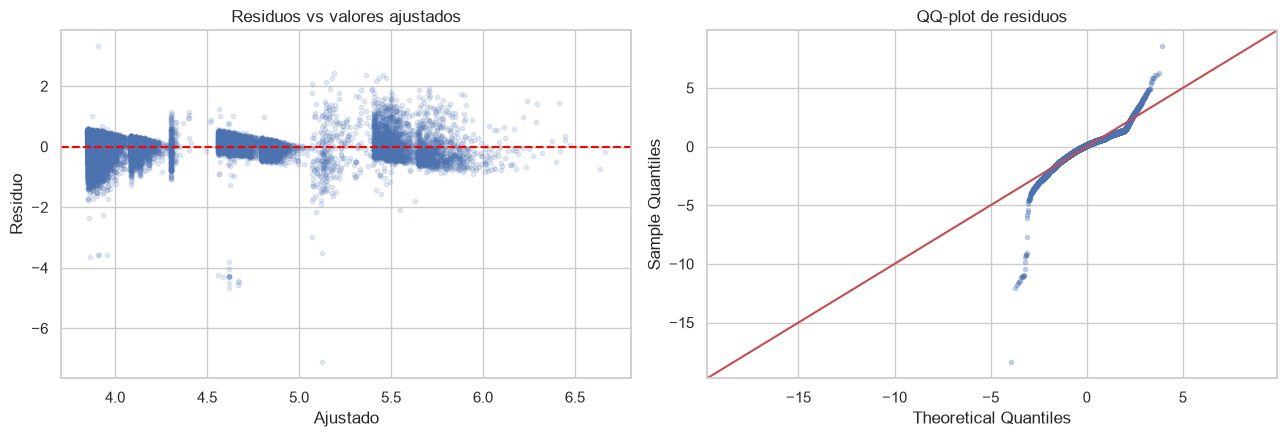

In [17]:
# Gráfico 4 — Diagnóstico de residuos
resid, fitted = reg.resid, reg.fittedvalues
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(fitted, resid, alpha=0.15, s=10); ax[0].axhline(0, color='red', ls='--')
ax[0].set(title='Residuos vs valores ajustados', xlabel='Ajustado', ylabel='Residuo')
sm.qqplot(resid, line='45', fit=True, ax=ax[1], markersize=3, alpha=0.3)
ax[1].set_title('QQ-plot de residuos')
plt.tight_layout(); plt.show()

**Interpretación y conclusión.** El modelo explica el **66,3% de la variabilidad** del log-monto (**R² = 0,663**) y la **prueba F global es altamente significativa** (F ≈ 4.914; p ≈ 0), por lo que el conjunto de predictores es relevante. Todos los coeficientes son significativos (p < 0,01). Lecturas destacadas (cada coeficiente es el cambio en log₁₀ del monto, *ceteris paribus*):
- **Modalidad** es el factor de mayor peso: respecto de *Concurso de Ofertas* (categoría base), la **Contratación Directa** se asocia a montos **mucho menores** (−0,71 en log₁₀ ≈ **−80%**), mientras que la **Licitación Pública Nacional** se asocia a montos **mayores** (+0,85 ≈ **×7**). Coherente: los procesos competitivos formales canalizan las compras de mayor cuantía.
- **N.º de oferentes:** +0,024 por oferente adicional ⇒ cada oferente extra se asocia a ≈ **+5,7%** de monto (relación positiva pero débil, r = 0,28).
- **Tipo:** las **Obras** implican mayor monto que Bienes (+0,24 en log₁₀, ≈ +72%), a igualdad del resto de factores.
- Los residuos (Gráfico 4) están razonablemente centrados en cero; el QQ-plot muestra colas algo pesadas, limitación esperable dada la naturaleza de los datos.

## 8. Resumen ejecutivo

Se analizaron **23.982 contrataciones públicas adjudicadas** del Paraguay (portal DNCP, 2021–2022). Los montos licitados son muy dispares: la mitad de los procesos no supera los **~20.000 USD**, pero unos pocos contratos de gran envergadura (obras) elevan fuertemente el promedio. Estimamos, con 95% de confianza, que el **monto típico** (media geométrica) de una contratación ronda los **23.000–24.000 USD**, y que **aproximadamente 2 de cada 3 procesos** reciben más de una oferta.

Al comparar años surgen dos señales claras y estadísticamente significativas: entre 2021 y 2022 el **monto típico creció** (de ≈17.000 a ≈26.000 USD), mientras que la **competencia disminuyó** (del 72% al 63% de procesos con más de un oferente). En otras palabras, se contrató por montos mayores pero con menos concurrencia.

Finalmente, el **tipo de compra** y sobre todo la **modalidad** son determinantes del monto: las **obras** y las **licitaciones públicas** concentran los importes más altos, mientras que la **contratación directa** —la modalidad más frecuente— se asocia a montos mucho menores. Un modelo estadístico con estas variables explica cerca de **dos tercios** de la variación de los montos. Estos resultados ofrecen una base cuantitativa para monitorear la **transparencia y la eficiencia** del gasto público paraguayo.

---
*Fuente de datos: Dirección Nacional de Contrataciones Públicas (DNCP), Paraguay — datos abiertos en estándar OCDS. Período 2021–2022.*